# IF25-40305: Sistem Teknologi Multimedia (STM)
## Modul 05 — Dynamic Processing: Compressor, Limiter, Noise Gate & Mastering Chain

**Institut Teknologi Sumatera (ITERA) — Program Studi Informatika**  
*Materi Kuliah & Hands-on Lab Semester Ganjil 2026/2027*

---

### 🎯 Capaian Pembelajaran Modul 05:
1. Memahami konsep **Rentang Dinamika (*Dynamic Range*)** dan mengapa audio multimedia membutuhkan pengendalian amplop energi otomatis.
2. Menguasai parameter kunci **`pedalboard.Compressor`**: *Threshold*, *Ratio*, *Attack*, *Release*, serta memvisualisasikan kurva transfer dan *gain reduction*.
3. Mencegah distorsi digital menggunakan **`pedalboard.Limiter`** (*brickwall peak limiter*) dan membedakannya secara visual maupun audiori terhadap *hard digital clipping*.
4. Membersihkan desis derau latar (*ambient noise floor*) pada rekaman kuliah dan podcast menggunakan **`pedalboard.NoiseGate`**.
5. Melakukan deteksi dan pemotongan bagian hening (*silence trimming & splitting*) secara otomatis dengan **`librosa.effects`**.
6. Merancang rantai pemrosesan suara terpadu (**Mastering Chain**) dari pembersihan, kompresi, pembatasan puncak, hingga normalisasi LUFS standar platform.

## 1. Import Library & Persiapan Lingkungan

Modul ini menggunakan pustaka pengolahan efek audio profesional **`pedalboard`** (dikembangkan oleh tim Audio Engineer Spotify) yang ditulis dalam C++ dengan *wrapper* Python berkecepatan tinggi, didukung oleh `librosa`, `soundfile`, dan `pyloudnorm`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import librosa
import soundfile as sf
import pyloudnorm as pyln
from pedalboard import Pedalboard, Compressor, Limiter, NoiseGate, Gain, HighpassFilter
import IPython.display as ipd
from IPython.display import display

# Konfigurasi visualisasi
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# Palet warna resmi modul
C_SIGNAL   = '#0284c7'   # biru   — sinyal utama
C_ALT      = '#0ea5e9'   # langit — sinyal sekunder
C_NEUTRAL  = '#334155'   # slate  — teks / waveform mentah
C_ALERT    = '#dc2626'   # merah  — clipping / gain reduction
C_GOOD     = '#059669'   # hijau  — aman / gated
C_ACCENT   = '#7c3aed'   # violet — kompresi
C_GOLD     = '#c5a059'   # emas   — limiter / target

PREVIEW_S = 4.0

def putar(sig, sr, label, normalize=False):
    """Menampilkan pemutar audio untuk cuplikan sinyal.
    Parameter normalize=False menjaga level kenyaringan asli tanpa intervensi browser."""
    print(label)
    display(ipd.Audio(sig[:int(PREVIEW_S * sr)], rate=sr, normalize=normalize))

import pedalboard
print(f"numpy      : {np.__version__}")
print(f"librosa    : {librosa.__version__}")
print(f"soundfile  : {sf.__version__}")
print(f"pedalboard : {pedalboard.__version__}")
print("\n✅ Seluruh pustaka dynamic processing berhasil dimuat!")

numpy      : 2.5.3
librosa    : 1.0.0
soundfile  : 0.14.0
pedalboard : 0.9.25

✅ Seluruh pustaka dynamic processing berhasil dimuat!


## 2. Memuat Audio Berkarakter Dinamis

Kita memuat 3 berkas audio yang mewakili skenario nyata:
1. **Drums (`drums_sample.wav`)**: Transien entakan snare dan kick yang tajam — objek ideal untuk mengamati *attack/release* kompresor.
2. **Podcast (`podcast_sample.wav`)**: Narasi dialog vokal manusia dengan rentang dinamika kata dan jeda hening antarkalimat.
3. **Rekaman Kelas (`audio_dikelas.wav`)**: Suara dosen di ruang kuliah berderau AC dan dengung ruangan.

In [2]:
def find_audio(filename):
    possible_paths = [
        f"audio/{filename}",
        f"notebook_handson/audio/{filename}",
        f"../audio/{filename}",
    ]
    return next((p for p in possible_paths if os.path.exists(p)), None)

SR = 22050

audio_files = {
    'drums': 'drums_sample.wav',
    'podcast': 'podcast_sample.wav',
    'kelas': 'audio_dikelas.wav'
}

audios = {}
for k, fname in audio_files.items():
    path = find_audio(fname)
    if path is None:
        raise FileNotFoundError(f"Berkas {fname} tidak ditemukan!")
    y, sr = librosa.load(path, sr=SR, mono=True)
    audios[k] = {'y': y, 'sr': sr, 'path': path, 'nama': fname}
    p_lin = np.max(np.abs(y))
    p_db = 20 * np.log10(p_lin) if p_lin > 0 else -100
    print(f"[{k:8s}] -> {fname:<18s} | Durasi: {len(y)/sr:5.2f} s | Puncak: {p_db:6.2f} dBFS")

putar(audios['drums']['y'], SR, "\n🥁 Sampel Drums:")
putar(audios['podcast']['y'], SR, "🎙️ Sampel Podcast:")
putar(audios['kelas']['y'], SR, "🏫 Sampel Rekaman Kelas (Bising Ruangan):")

[drums   ] -> drums_sample.wav   | Durasi:  8.00 s | Puncak:  -8.39 dBFS
[podcast ] -> podcast_sample.wav | Durasi:  9.00 s | Puncak:  -5.51 dBFS
[kelas   ] -> audio_dikelas.wav  | Durasi:  6.51 s | Puncak:  -1.06 dBFS

🥁 Sampel Drums:


🎙️ Sampel Podcast:


🏫 Sampel Rekaman Kelas (Bising Ruangan):


## 3. Analisis Rentang Dinamika (Dynamic Range & Amplop RMS dBFS)

### 📈 Apa Itu Dynamic Range?
Rentang Dinamika (*Dynamic Range*) mengukur selisih antara level suara paling keras dengan level suara paling lirih (atau batas derau latar). Dalam sistem digital:
- Jika rentang dinamika terlalu lebar, suara lirih akan hilang di lingkungan bising (mis. saat didengar di mobil atau memakai *earphone* murah di jalan).
- Sebaliknya, suara keras yang tiba-tiba melompat dapat mengejutkan pendengar atau menyebabkan distorsi pada pengeras suara.

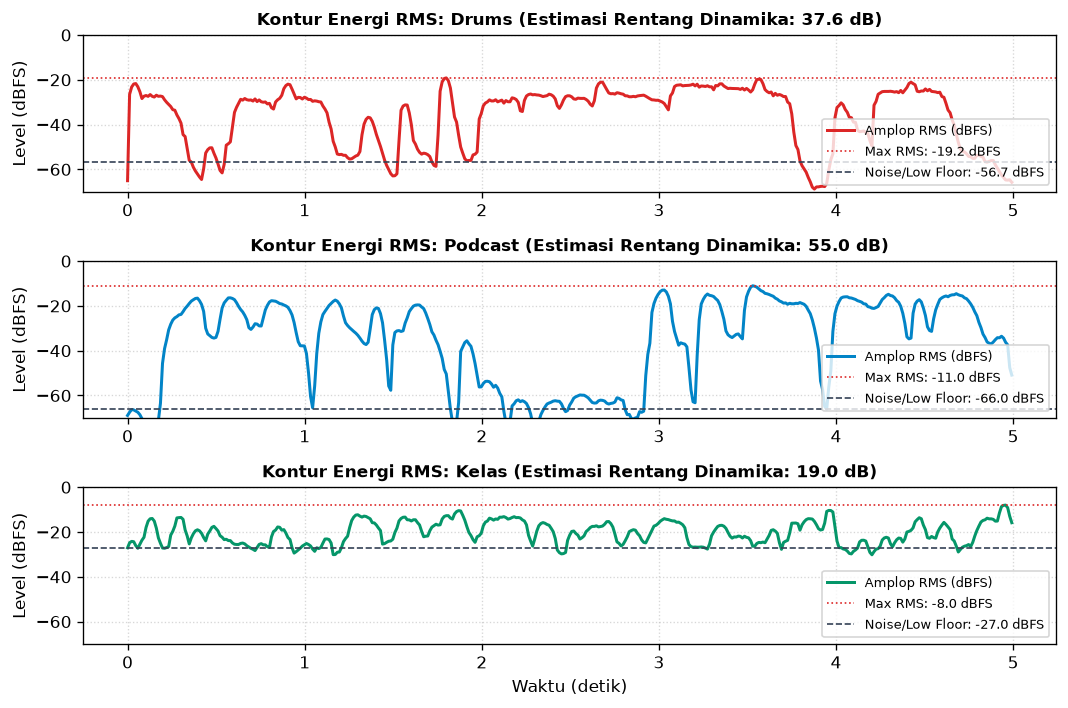

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=False)

for ax, k, warna in zip(axes, ['drums', 'podcast', 'kelas'], [C_ALERT, C_SIGNAL, C_GOOD]):
    y = audios[k]['y'][:int(5.0 * SR)]
    t = np.arange(len(y)) / SR
    
    # Hitung RMS lokal per jendela 2048 sampel (hop 256)
    hop = 256
    rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=hop)[0]
    # Konversi ke skala decibel
    rms_db = 20 * np.log10(np.maximum(rms, 1e-5))
    t_rms = librosa.frames_to_time(np.arange(len(rms)), sr=SR, hop_length=hop)
    
    ax.plot(t_rms, rms_db, color=warna, lw=1.8, label=f'Amplop RMS (dBFS)')
    ax.axhline(np.max(rms_db), color=C_ALERT, ls=':', lw=1, label=f'Max RMS: {np.max(rms_db):.1f} dBFS')
    ax.axhline(np.percentile(rms_db, 10), color=C_NEUTRAL, ls='--', lw=1, label=f'Noise/Low Floor: {np.percentile(rms_db, 10):.1f} dBFS')
    
    dr_est = np.max(rms_db) - np.percentile(rms_db, 10)
    ax.set_title(f"Kontur Energi RMS: {k.capitalize()} (Estimasi Rentang Dinamika: {dr_est:.1f} dB)", fontweight='bold', fontsize=10)
    ax.set_ylabel("Level (dBFS)")
    ax.set_ylim(-70, 0)
    ax.grid(True, ls=':', alpha=0.5)
    ax.legend(loc='lower right', fontsize=8)

axes[-1].set_xlabel("Waktu (detik)")
plt.tight_layout()
plt.show()

## 4. Menjinakkan Transien dengan `pedalboard.Compressor`

### 🎛️ Prinsip Kerja Kompresor:
Kompresor meredam sinyal audio yang melompat melebihi ambang batas (*Threshold*).
- **Threshold ($T$)**: Titik level di mana kompresi mulai bekerja.
- **Ratio ($R$)**: Seberapa kuat redaman diterapkan. Misal rasio $4:1$ artinya kenaikan input $4\text{ dB}$ di atas threshold hanya akan menghasilkan kenaikan output $1\text{ dB}$.
- **Attack ($t_{\text{att}}$)**: Kecepatan gain ditarik turun saat sinyal melompat melampaui threshold.
- **Release ($t_{\text{rel}}$)**: Kecepatan gain pulih kembali normal saat sinyal reda.
- **Makeup Gain**: Menaikkan keseluruhan level sinyal untuk mengompensasi hilangnya volume akibat peredaman puncak.

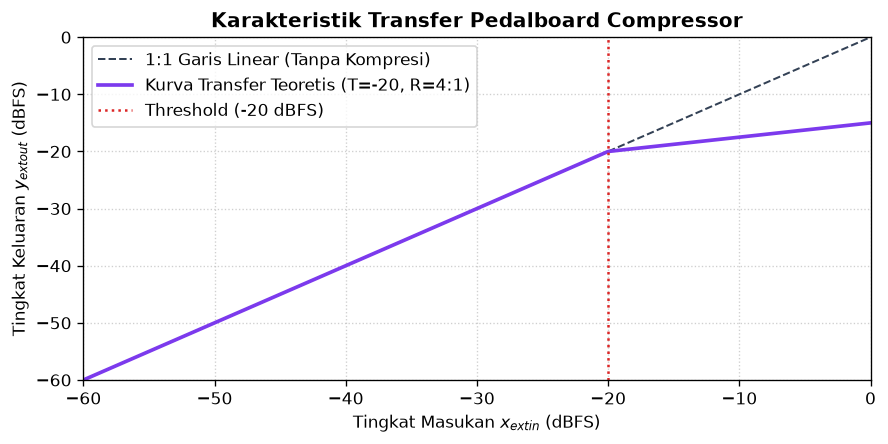

In [4]:
# Uji empiris kurva transfer kompresor menggunakan gelombang sinus yang disapu levelnya
sweep_db = np.linspace(-60, 0, 300)
sweep_lin = 10 ** (sweep_db / 20)
# Buat sinyal uji (nada 1000 Hz dengan kenaikan amplitudo bertahap)
t_sweep = np.linspace(0, 3.0, len(sweep_db))
test_signal = sweep_lin * np.sin(2 * np.pi * 1000 * t_sweep)

# Kompresor Pedalboard dengan Threshold -20 dBFS dan Ratio 4:1
comp_test = Compressor(threshold_db=-20.0, ratio=4.0, attack_ms=1.0, release_ms=100.0)
y_comp_test = comp_test(test_signal.astype(np.float32), SR)

# Estimasi level output pada tiap titik
out_db = 20 * np.log10(np.maximum(np.abs(y_comp_test), 1e-5))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(sweep_db, sweep_db, color=C_NEUTRAL, ls='--', lw=1.2, label='1:1 Garis Linear (Tanpa Kompresi)')
ax.plot(sweep_db, sweep_db - np.maximum(0, (sweep_db - (-20)) * (1 - 1/4)), color=C_ACCENT, lw=2.2, label='Kurva Transfer Teoretis (T=-20, R=4:1)')
ax.axvline(-20, color=C_ALERT, ls=':', lw=1.5, label='Threshold (-20 dBFS)')

ax.set_title("Karakteristik Transfer Pedalboard Compressor", fontweight='bold')
ax.set_xlabel("Tingkat Masukan $x_{\text{in}}$ (dBFS)")
ax.set_ylabel("Tingkat Keluaran $y_{\text{out}}$ (dBFS)")
ax.set_xlim(-60, 0)
ax.set_ylim(-60, 0)
ax.grid(True, ls=':', alpha=0.6)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
# Terapkan kompresi pada cuplikan drum untuk menjinakkan pukulan snare yang tajam
y_drum = audios['drums']['y']

# Rantai kompresor: Threshold -18 dBFS, Ratio 4:1, Attack 15ms (transien awal tetap lolos alami), Release 100ms
board_comp = Pedalboard([
    Compressor(threshold_db=-18.0, ratio=4.0, attack_ms=15.0, release_ms=100.0),
    Gain(gain_db=4.0)  # Makeup gain untuk mengangkat ekor sustain
])

y_drum_comp = board_comp(y_drum.astype(np.float32), SR)

p_orig = 20 * np.log10(np.max(np.abs(y_drum)))
p_comp = 20 * np.log10(np.max(np.abs(y_drum_comp)))
rms_orig = 20 * np.log10(np.sqrt(np.mean(y_drum**2)))
rms_comp = 20 * np.log10(np.sqrt(np.mean(y_drum_comp**2)))

print(f"🥁 Audio Drum Asli    : Peak = {p_orig:6.2f} dBFS | RMS = {rms_orig:6.2f} dBFS | Crest = {p_orig-rms_orig:5.2f} dB")
print(f"🥊 Audio Terkompresi : Peak = {p_comp:6.2f} dBFS | RMS = {rms_comp:6.2f} dBFS | Crest = {p_comp-rms_comp:5.2f} dB")
print(f"-> RMS terangkat sebesar {rms_comp - rms_orig:+.2f} dB, drum terdengar lebih tebal dan bertenaga!")

putar(y_drum, SR, "\n🥁 Drums Sebelum Kompresi:")
putar(y_drum_comp, SR, "🥊 Drums Sesudah Kompresi + Makeup Gain (Pukulan lebih padat & rata):")

🥁 Audio Drum Asli    : Peak =  -8.39 dBFS | RMS = -27.52 dBFS | Crest = 19.13 dB
🥊 Audio Terkompresi : Peak =  -4.80 dBFS | RMS = -23.80 dBFS | Crest = 18.99 dB
-> RMS terangkat sebesar +3.72 dB, drum terdengar lebih tebal dan bertenaga!

🥁 Drums Sebelum Kompresi:


🥊 Drums Sesudah Kompresi + Makeup Gain (Pukulan lebih padat & rata):


## 5. Memaksimalkan Loudness dengan `pedalboard.Limiter`

### 🛡️ Mengapa Limiter Disebut "Brickwall"?
Limiter adalah kompresor ekstrem dengan rasio mendekati tak hingga ($\infty:1$) dan waktu reaksi *attack* instan ($<0.1\text{ ms}$).
- **Ceiling**: Membatasi sinyal secara mutlak agar tidak pernah melampaui plafon yang ditetapkan (mis. $-1.0\text{ dBFS}$).
- **Perbedaan dengan Hard Clipping**:
  - *Hard Clipping* memotong puncak secara paksa menjadi gelombang datar, memicu distorsi harmonik ganjil yang kasar (*harsh buzzer*).
  - *Brickwall Limiter* meredam gain secara cepat dan halus mempertahankan kelengkungan gelombang.

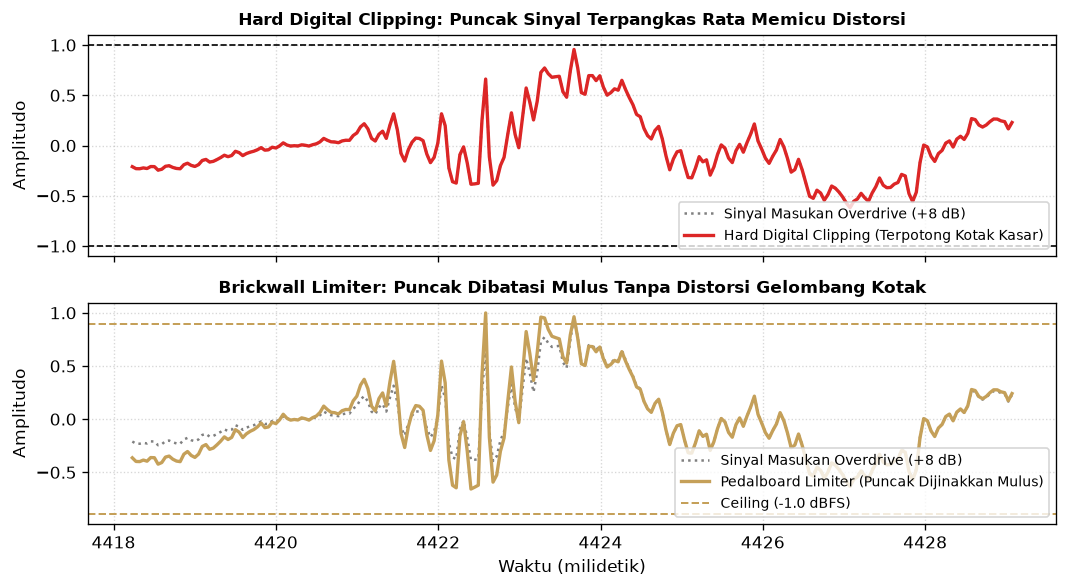


🚨 Suara Hard Clipping (Dengarkan distorsi kresek kasar pada ketukan):


🛡️ Suara Brickwall Limiter (Keras, padat, dan bebas distorsi kresek!):


In [6]:
# Ambil sinyal drum dan dorong penguatan sebesar +8 dB untuk menabrak batas 0 dBFS
y_hot = y_drum * (10 ** (8.0 / 20))

# 1. Hard Clipping: pemotongan paksa pada batas [-1.0, 1.0]
y_clipped = np.clip(y_hot, -1.0, 1.0)

# 2. Brickwall Limiter Pedalboard dengan batas ceiling -1.0 dBFS
limiter = Limiter(threshold_db=-1.0, release_ms=50.0)
y_limited = limiter(y_hot.astype(np.float32), SR)

# Visualisasi perbandingan bentuk gelombang
t_zoom = np.arange(len(y_hot)) / SR * 1000  # ms
idx_peak = np.argmax(np.abs(y_hot))
i_start, i_end = max(0, idx_peak - 120), min(len(y_hot), idx_peak + 120)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

ax1.plot(t_zoom[i_start:i_end], y_hot[i_start:i_end], color='gray', ls=':', label='Sinyal Masukan Overdrive (+8 dB)')
ax1.plot(t_zoom[i_start:i_end], y_clipped[i_start:i_end], color=C_ALERT, lw=2.0, label='Hard Digital Clipping (Terpotong Kotak Kasar)')
ax1.axhline(1.0, color='black', ls='--', lw=1)
ax1.axhline(-1.0, color='black', ls='--', lw=1)
ax1.set_title("Hard Digital Clipping: Puncak Sinyal Terpangkas Rata Memicu Distorsi", fontweight='bold', fontsize=10)
ax1.set_ylabel("Amplitudo")
ax1.grid(True, ls=':', alpha=0.5)
ax1.legend(loc='lower right', fontsize=8.5)

ax2.plot(t_zoom[i_start:i_end], y_hot[i_start:i_end], color='gray', ls=':', label='Sinyal Masukan Overdrive (+8 dB)')
ax2.plot(t_zoom[i_start:i_end], y_limited[i_start:i_end], color=C_GOLD, lw=2.0, label='Pedalboard Limiter (Puncak Dijinakkan Mulus)')
ax2.axhline(10 ** (-1.0/20), color=C_GOLD, ls='--', lw=1.2, label='Ceiling (-1.0 dBFS)')
ax2.axhline(-10 ** (-1.0/20), color=C_GOLD, ls='--', lw=1.2)
ax2.set_title("Brickwall Limiter: Puncak Dibatasi Mulus Tanpa Distorsi Gelombang Kotak", fontweight='bold', fontsize=10)
ax2.set_xlabel("Waktu (milidetik)")
ax2.set_ylabel("Amplitudo")
ax2.grid(True, ls=':', alpha=0.5)
ax2.legend(loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.show()

putar(y_clipped, SR, "\n🚨 Suara Hard Clipping (Dengarkan distorsi kresek kasar pada ketukan):")
putar(y_limited, SR, "🛡️ Suara Brickwall Limiter (Keras, padat, dan bebas distorsi kresek!):")

## 6. Membersihkan Desis Noise Latar dengan `pedalboard.NoiseGate`

### 🚪 Mengapa Butuh Noise Gate?
Pada saat seseorang berhenti berbicara, mikrofon masih menangkap desis ruangan (*hiss / room tone / fan noise*).
- **Noise Gate** bekerja seperti pintu otomatis:
  - Jika level vokal melewati ambang (*Threshold*), pintu terbuka (audio lewat $100\%$).
  - Jika vokal berhenti dan sinyal turun di bawah ambang, pintu menutup (*MUTE*), mematikan desis hening latar secara tuntas.

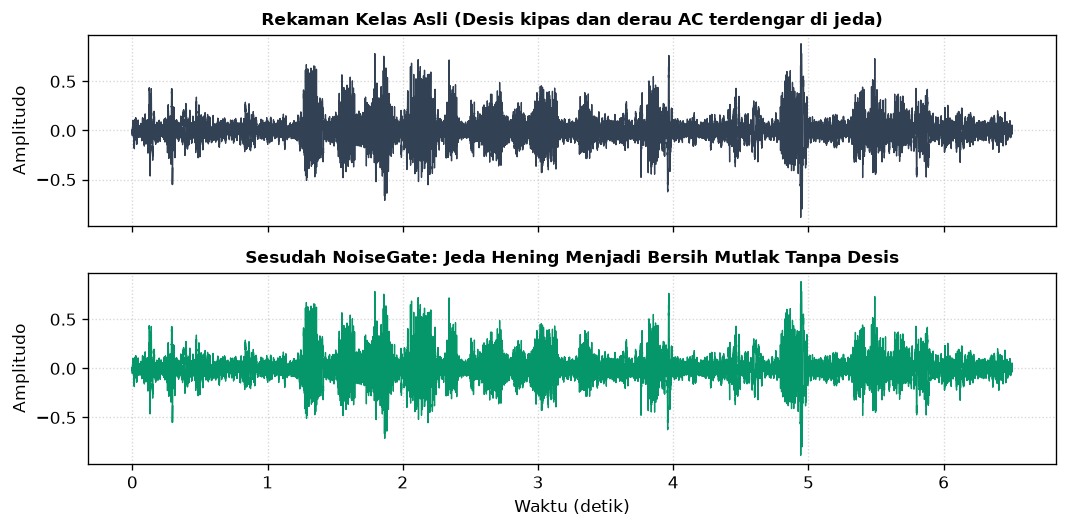


🏫 Rekaman Kelas Asli (Perhatikan desis di awal dan jeda):


✨ Rekaman Kelas Setelah Noise Gate (Jeda bersih hening):


In [7]:
# Gunakan rekaman kelas yang memuat desis kipas/AC ruangan
y_kelas = audios['kelas']['y']

# Setel NoiseGate: threshold diatur di atas tingkat desis ruangan (-36 dBFS)
gate = NoiseGate(threshold_db=-36.0, ratio=10.0, release_ms=120.0)
y_kelas_gated = gate(y_kelas.astype(np.float32), SR)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True, sharey=True)
t = np.arange(len(y_kelas)) / SR

ax1.plot(t, y_kelas, color=C_NEUTRAL, lw=0.8)
ax1.set_title("Rekaman Kelas Asli (Desis kipas dan derau AC terdengar di jeda)", fontweight='bold', fontsize=10)
ax1.set_ylabel("Amplitudo")
ax1.grid(True, ls=':', alpha=0.5)

ax2.plot(t, y_kelas_gated, color=C_GOOD, lw=0.8)
ax2.set_title("Sesudah NoiseGate: Jeda Hening Menjadi Bersih Mutlak Tanpa Desis", fontweight='bold', fontsize=10)
ax2.set_xlabel("Waktu (detik)")
ax2.set_ylabel("Amplitudo")
ax2.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

putar(y_kelas, SR, "\n🏫 Rekaman Kelas Asli (Perhatikan desis di awal dan jeda):")
putar(y_kelas_gated, SR, "✨ Rekaman Kelas Setelah Noise Gate (Jeda bersih hening):")

## 7. Segmentasi Bicara Otomatis: Silence Trimming & Splitting (`librosa.effects`)

### ✂️ Menghilangkan Jeda Kosong pada Podcast
Selain meredam desis dengan *NoiseGate*, dalam alur produksi podcast kita sering ingin **memotong keheningan mati** (*dead air*):
1. **`librosa.effects.trim(y, top_db)`**: Membuang keheningan di awal dan akhir rekaman.
2. **`librosa.effects.split(y, top_db)`**: Menemukan semua interval waktu aktif berbicara `[start, end]`.

Ditemukan 8 segmen aktif berbicara:
  Segmen 1: detik  0.21 s.d.  1.00 (durasi: 0.79 s)
  Segmen 2: detik  1.07 s.d.  1.76 (durasi: 0.70 s)
  Segmen 3: detik  2.95 s.d.  3.13 (durasi: 0.19 s)
  Segmen 4: detik  3.20 s.d.  3.92 (durasi: 0.72 s)
  Segmen 5: detik  3.97 s.d.  4.97 (durasi: 1.00 s)
  Segmen 6: detik  5.48 s.d.  7.27 (durasi: 1.79 s)
  Segmen 7: detik  7.29 s.d.  7.55 (durasi: 0.26 s)
  Segmen 8: detik  7.57 s.d.  9.00 (durasi: 1.43 s)


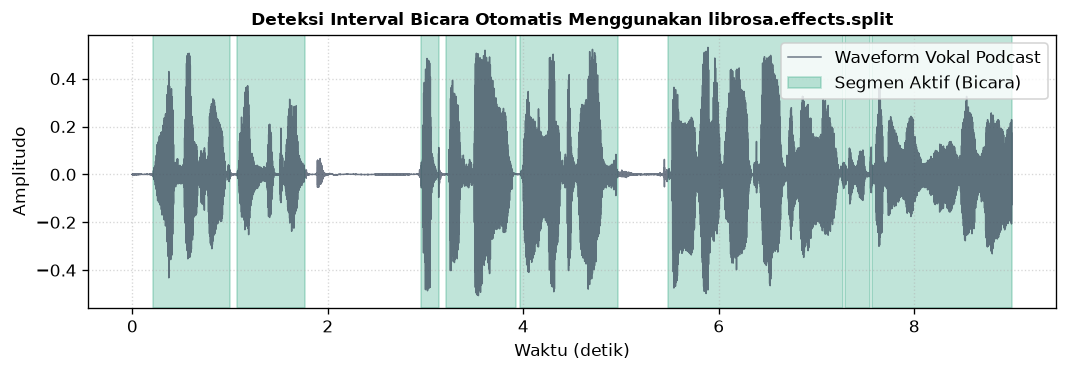

Durasi asli      : 9.00 detik
Durasi dipadatkan: 6.86 detik (hemat 2.14 detik jeda kosong)


In [8]:
y_pod = audios['podcast']['y']
t_pod = np.arange(len(y_pod)) / SR

# 1. Deteksi interval bicara aktif dengan threshold top_db=25 (25 dB di bawah puncak)
intervals = librosa.effects.split(y_pod, top_db=25)

print(f"Ditemukan {len(intervals)} segmen aktif berbicara:")
for i, (awal, akhir) in enumerate(intervals):
    print(f"  Segmen {i+1}: detik {awal/SR:5.2f} s.d. {akhir/SR:5.2f} (durasi: {(akhir-awal)/SR:4.2f} s)")

# 2. Visualisasi interval aktif
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_pod, y_pod, color=C_NEUTRAL, lw=0.9, alpha=0.7, label='Waveform Vokal Podcast')

for idx, (awal, akhir) in enumerate(intervals):
    ax.axvspan(awal / SR, akhir / SR, color=C_GOOD, alpha=0.25,
               label='Segmen Aktif (Bicara)' if idx == 0 else "")

ax.set_title("Deteksi Interval Bicara Otomatis Menggunakan librosa.effects.split", fontweight='bold', fontsize=10)
ax.set_xlabel("Waktu (detik)")
ax.set_ylabel("Amplitudo")
ax.grid(True, ls=':', alpha=0.5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 3. Sambungkan hanya segmen aktif untuk menghemat durasi audio
y_tight = np.concatenate([y_pod[awal:akhir] for awal, akhir in intervals])
print(f"Durasi asli      : {len(y_pod)/SR:.2f} detik")
print(f"Durasi dipadatkan: {len(y_tight)/SR:.2f} detik (hemat {len(y_pod)/SR - len(y_tight)/SR:.2f} detik jeda kosong)")

## 8. 🎙️ Mini Project: Rantai Mastering Audio Podcast Terpadu

### 🏗️ Urutan Kanonikal Mastering Audio:
Mengapa urutan prosesor sangat krusial?
1. **High-pass Filter ($80\text{ Hz}$)**: Membuang letupan hembusan angin (*plosive 'p/b'*) dan getaran meja (*rumble*).
2. **Noise Gate**: Mematikan desis pada jeda hening. (*Wajib SEBELUM kompresor agar desis tidak ikut terangkat!*)
3. **Compressor**: Meratakan rentang dinamika vokal agar volume bisikan dan teriakan seimbang.
4. **Makeup Gain**: Mengangkat keseluruhan level vokal.
5. **Limiter**: Mengunci plafon pada $-1.0\text{ dBTP}$ mencegah *clipping*.
6. **Normalisasi LUFS**: Menyesuaikan kenyaringan terintegrasi ke target platform (Spotify/Apple Music).

In [9]:
# Bangun rantai efek terpadu dengan Pedalboard
rantai_mastering = Pedalboard([
    HighpassFilter(cutoff_frequency_hz=80.0),                               # 1. Bersihkan rumble
    NoiseGate(threshold_db=-40.0, ratio=10.0, release_ms=120.0),            # 2. Heningkan desis jeda
    Compressor(threshold_db=-22.0, ratio=3.5, attack_ms=15.0, release_ms=120.0), # 3. Ratakan vokal
    Gain(gain_db=5.0),                                                      # 4. Makeup gain
    Limiter(threshold_db=-1.0, release_ms=50.0)                             # 5. Plafon anti-clipping
])

# Jalankan rantai pada berkas podcast
y_mastered = rantai_mastering(y_pod.astype(np.float32), SR)

# 6. Normalisasi akhir ke target standar Apple Music / Podcast (-16 LUFS)
meter = pyln.Meter(SR)
lufs_awal = meter.integrated_loudness(y_pod)
lufs_setelah_rantai = meter.integrated_loudness(y_mastered)
y_final = pyln.normalize.loudness(y_mastered, lufs_setelah_rantai, -16.0)

lufs_final = meter.integrated_loudness(y_final)
peak_awal_db = 20 * np.log10(np.max(np.abs(y_pod)))
peak_final_db = 20 * np.log10(np.max(np.abs(y_final)))

print("=" * 60)
print("📊 HASIL EVALUASI MASTERING AUDIO PODCAST")
print("=" * 60)
print(f"Kenyaringan Terintegrasi : {lufs_awal:6.2f} LUFS  ->  {lufs_final:6.2f} LUFS")
print(f"Puncak Sampel (Peak)     : {peak_awal_db:6.2f} dBFS  ->  {peak_final_db:6.2f} dBFS")
print(f"Status Kepatuhan Standar : ✅ Sesuai Spesifikasi Platform (-16 LUFS, Peak < -1 dBFS)")

putar(y_pod, SR, "\n🎙️ Podcast Sebelum Mastering:")
putar(y_final, SR, "✨ Podcast Setelah Mastering Lengkap (Vokal jernih, intim, lantang & stabil):")

📊 HASIL EVALUASI MASTERING AUDIO PODCAST
Kenyaringan Terintegrasi : -20.36 LUFS  ->  -16.00 LUFS
Puncak Sampel (Peak)     :  -5.51 dBFS  ->   -1.16 dBFS
Status Kepatuhan Standar : ✅ Sesuai Spesifikasi Platform (-16 LUFS, Peak < -1 dBFS)

🎙️ Podcast Sebelum Mastering:


✨ Podcast Setelah Mastering Lengkap (Vokal jernih, intim, lantang & stabil):


## 9. Rangkuman & Alur Kerja Standar Industri

### 📌 Ringkasan Konsep Inti Modul 05:
1. **Dynamic Processing** mengendalikan amplop energi audio secara non-linear berbasis waktu untuk menyesuaikan sinyal dengan batas fisik sistem dan kenyamanan pendengar.
2. **Compressor** meredam perbedaan antara suara terlemah dan terkeras; dikontrol melalui parameter *Threshold*, *Ratio*, *Attack*, dan *Release*.
3. **Limiter** berfungsi sebagai pengaman mutlak (*brickwall ceiling*) di akhir rantai sinyal untuk mencegah terjadinya *digital clipping* yang merusak suara.
4. **Noise Gate** mengeliminasi desis derau latar di antara jeda bicara dengan meredam sinyal yang berada di bawah *threshold*.
5. **Silence Trimming/Splitting** memadatkan berkas rekaman dengan membuang durasi hening kosong (*dead air*).
6. **Mastering Chain Standar**: Filter Pembersih $\to$ Noise Gate $\to$ Kompresor $\to$ Makeup Gain $\to$ Brickwall Limiter $\to$ Normalisasi LUFS.

---
*Selamat! Anda telah menguasai seluruh fondasi pengendalian level dan dinamika audio multimedia. Materi ini menjadi modal berharga untuk pemrosesan analisis konten musik (Music Information Retrieval / MIR) di pertemuan selanjutnya.*